# Final Project: Finding Pittsburgh's Best Neighborhood - A Habitability Analysis
**Team:** Final Project Group 7  
**Members:** 
- **Mingyu Chen**: Safety
- **Xiaoting Wang**: Convenience
- **Yixuan Chen**: Environment

## 1. Introduction
Our project addresses the subjective question: "What is the best neighborhood in Pittsburgh?" using a data-driven **Habitability Index**. We define "best" as a balance between safety, environmental health, and commercial convenience. 

## 2. The Metric & Data Integration Logic
We used three sub-metrics from the WPRDC:
1. **Safety (Police Incident Data)**: Lower incident counts = Better rank.
2. **Environment (City Trees)**: Higher tree density = Better rank.
3. **Convenience (Parking Rates)**: Lower hourly rates = Better rank.

### Handling Missing Data: The "Infrastructure Penalty"

A unique challenge we encountered was the limited coverage of the parking rate dataset (`parkingRates.csv`), which only records zones with paid commercial infrastructure and primarily covers business districts (e.g., Downtown, Oakland). Our team decided to treat this not as a data "hole", but as a **meaningful indicator**. Neighborhoods without parking meters are treated as lacking mature commercial infrastructure, and thus receive a penalizing rank in the Convenience category.

- **Implementation**: Neighborhoods missing from the convenience dataset are assigned a rank equal to the **Maximum Rank + 3**. This ensures they are penalized for the lack of infrastructure while still being evaluated on safety and environment.

### Final Scoring & Tie-breaking
- **Final Score**: `(Safety_Rank + Environment_Rank + Convenience_Rank) / 3` (Lowest is best).
- **Tie-breaker Strategy**: If scores are equal, the tie is broken in order of priority: **Safety > Environment > Convenience**.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_p = pd.read_csv('the_Police_Incident_Data.csv', low_memory=False)
df_t = pd.read_csv('City of Pittsburgh Trees-Dataset.csv', low_memory=False)
df_c = pd.read_csv('parkingRates.csv')

df_p['Neighborhood'] = df_p['Neighborhood'].replace({'St. Clair': 'Saint Clair'})
safety = df_p[df_p['NIBRS_Offense_Category'] != 'Not NIBRS Reportable'].dropna(subset=['Neighborhood'])
safety_stats = safety['Neighborhood'].value_counts().reset_index()
safety_stats.columns = ['Neighborhood', 'Crime_Count']
safety_stats['Safety_Rank'] = safety_stats['Crime_Count'].rank(method='min', ascending=True)

tree_stats = df_t.dropna(subset=['neighborhood'])['neighborhood'].value_counts().reset_index()
tree_stats.columns = ['Neighborhood', 'Tree_Count']
tree_stats['Environment_Rank'] = tree_stats['Tree_Count'].rank(method='min', ascending=False)

df_c['rate_float'] = df_c['rate'].str.extract(r'(\d+\.\d+)').astype(float)
def map_zone(zone):
    z = str(zone).lower()
    if 'oakland' in z: return 'Central Oakland'
    if 'downtown' in z: return 'Central Business District'
    if 'shadyside' in z: return 'Shadyside'
    if 'squirrel hill' in z: return 'Squirrel Hill South'
    if 'south side' in z: return 'South Side Flats'
    if 'northside' in z or 'northshore' in z: return 'North Shore'
    if 'east liberty' in z: return 'East Liberty'
    if 'west end' in z: return 'West End'
    if 'brookline' in z: return 'Brookline'
    if 'lawrenceville' in z: return 'Central Lawrenceville'
    if 'bloomfield' in z: return 'Bloomfield'
    if 'strip' in z: return 'Strip District'
    if 'carrick' in z: return 'Carrick'
    if 'beechview' in z: return 'Beechview'
    if 'allentown' in z: return 'Allentown'
    if 'mt. washington' in z or 'washington' in z: return 'Mount Washington'
    if 'uptown' in z: return 'Bluff'
    return z.title()

df_c['Neighborhood'] = df_c['zone'].apply(map_zone)
parking_stats = df_c.groupby('Neighborhood')['rate_float'].mean().reset_index()
parking_stats['Convenience_Rank'] = parking_stats['rate_float'].rank(method='min', ascending=True)

In [5]:
merged = pd.merge(safety_stats, tree_stats, on='Neighborhood', how='inner')
final_df = pd.merge(merged, parking_stats, on='Neighborhood', how='left')

penalty_rank = parking_stats['Convenience_Rank'].max() + 3
final_df['Convenience_Rank'] = final_df['Convenience_Rank'].fillna(penalty_rank)

final_df['Final_Score'] = (final_df['Safety_Rank'] + final_df['Environment_Rank'] + final_df['Convenience_Rank']) / 3

final_df = final_df.sort_values(
    by=['Final_Score', 'Safety_Rank', 'Environment_Rank', 'Convenience_Rank'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("Final Top 10 Habitability Ranking:")
display(final_df[['Neighborhood', 'Final_Score', 'Safety_Rank', 'Environment_Rank', 'Convenience_Rank']].head(10))

Final Top 10 Habitability Ranking:


,Neighborhood,Final_Score,Safety_Rank,Environment_Rank,Convenience_Rank
0,Regent Square,18.666667,10.0,36.0,10.0
1,Stanton Heights,18.666667,26.0,20.0,10.0
2,Perry North,19.666667,40.0,9.0,10.0
3,Point Breeze,21.333333,46.0,8.0,10.0
4,Allegheny West,21.666667,14.0,41.0,10.0
5,Morningside,21.666667,23.0,32.0,10.0
6,Manchester,22.666667,39.0,19.0,10.0
7,Squirrel Hill North,23.000000,56.0,3.0,10.0
8,Highland Park,23.333333,58.0,2.0,10.0
9,Swisshelm Park,23.666667,6.0,55.0,10.0


## 3. The Best Neighborhood: Analysis Results
To visualize our findings, we plotted the final scores for the top-performing neighborhoods. **Note: Since these scores represent average ranks, a shorter bar (lower score) indicates a better overall performance.**

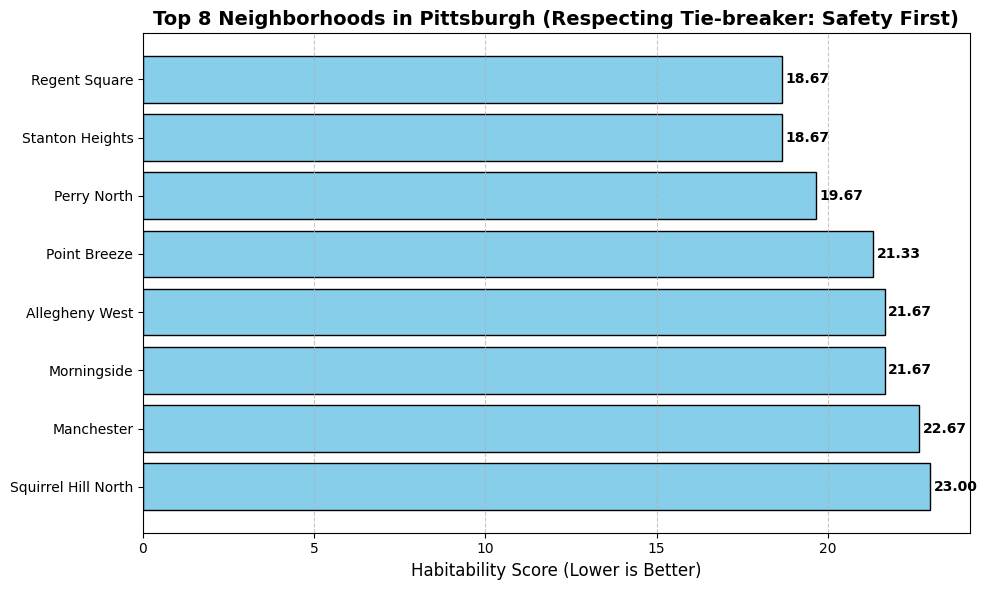

In [6]:
plt.figure(figsize=(10, 6))

top_8_display = final_df.head(8).iloc[::-1]

plt.barh(top_8_display['Neighborhood'], top_8_display['Final_Score'], color='skyblue', edgecolor='black')
plt.title('Top 8 Neighborhoods in Pittsburgh (Respecting Tie-breaker: Safety First)', fontsize=14, fontweight='bold')
plt.xlabel('Habitability Score (Lower is Better)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(top_8_display['Final_Score']):
    plt.text(v + 0.1, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Conclusion
Our analysis reveals that the "best" neighborhood is not necessarily the one that dominates a single category, but the one that maintains consistency. **Regent Square** effectively balances its top-tier safety and convenience rankings with adequate green space.

### Individual Reflections
- **Mingyu Chen (Safety):** My top neighborhood, Saint Clair, ranked lower in the final index because it received the "Infrastructure Penalty" for lacking public commercial facilities. This highlighted that while safety is a prerequisite, true habitability requires active commercial life.
- **Xiaoting Wang (Convenience):** Allentown was the most affordable, but its lower environmental ranking prevented it from winning. Our team decision to penalize missing data added a necessary layer of realism to the convenience metric.
- **Yixuan Chen (Environment):** Squirrel Hill South has the best trees but higher crime density. The rank-averaging method successfully moderated these extremes to find a balanced winner.